In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import transforms as T

import pytorch_lightning as pl

from torchmetrics.classification import Accuracy
from torchmetrics.aggregation import MeanMetric
from torchvision.datasets import MNIST

from datetime import datetime


from xaikd import datasets, utils, attributors

from tqdm.notebook import tqdm
from xaikd.bases import PRCAReconGreedy, PRCASignAlignGreedy


from zennit.attribution import Gradient
from zennit.composites import EpsilonGammaBox

from xaikd.bases import pcalookahead


In [2]:
!nproc

16


In [3]:
DEVICE = utils.get_device()
DEVICE

'cuda'

In [4]:
NUM_WORKERS = 16

DATA_SIZE = 0.5


In [5]:
ds_train = datasets.MultiTaskEMNISTFashionMNIST(
    train=True,
    root="../../datasets",
    transform=T.Compose(
        [
            T.ToTensor(),
            T.Normalize(
                0.5,
                0.5,
            ),
        ]
    )
)

ds_val = datasets.MultiTaskEMNISTFashionMNIST(
    train=False,
    root="../../datasets",
    transform=T.Compose(
        [
            T.ToTensor(),
            T.Normalize(
                0.5,
                0.5,
            ),
        ]
    )
)

In [6]:
TASK_NUM_CLASSES = ds_train.num_classes

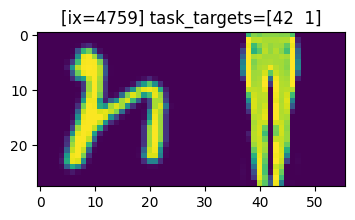

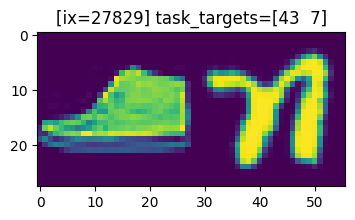

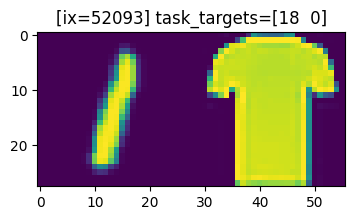

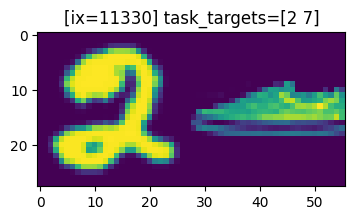

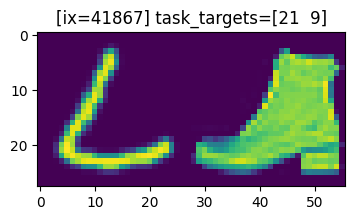

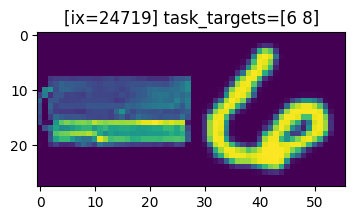

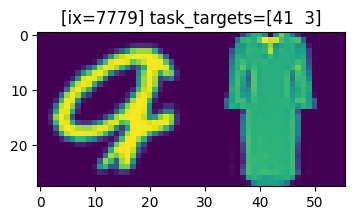

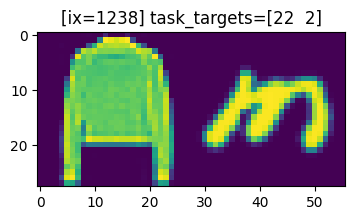

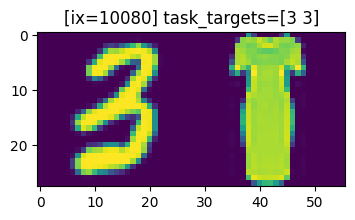

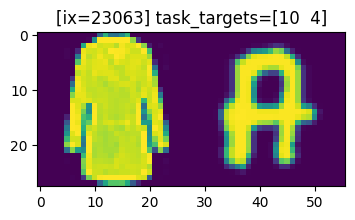

In [7]:
def ano():

    for ix in np.random.permutation(60000)[:10]:
        
        x, y = ds_train[ix]
    
        plt.figure(figsize=(2*2, 2))
        plt.imshow(x.squeeze())
        plt.title(f"[ix={ix}] task_targets={y}")
ano()

# Construct Model and Train

In [8]:
class CNN(nn.Module):
    def __init__(self, num_classes=10, d=256):
        super().__init__()
        self.conv1 = nn.Conv2d(kernel_size=3, out_channels=d, in_channels=1)
        self.act1 = nn.ReLU()
        self.max1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(kernel_size=3, out_channels=d, in_channels=d)
        self.act2 = nn.ReLU()
        self.max2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(kernel_size=3, out_channels=d, in_channels=d)
        self.act3 = nn.ReLU()
        self.avgpool = nn.AdaptiveAvgPool2d(output_size=1)
        
        self.fc_task_1 = nn.Linear(d, TASK_NUM_CLASSES[0])
        self.fc_task_2 = nn.Linear(d, TASK_NUM_CLASSES[1])

    def forward(self, x):
        x = self.act1(self.conv1(x))
        x = self.max1(x)
        
        x = self.act2(self.conv2(x))
        x = self.max2(x)
        
        x = self.act3(self.conv3(x))
        
        x = self.avgpool(x)
        x = torch.flatten(x, start_dim=1)
        out_task_1 = self.fc_task_1(x)
        out_task_2 = self.fc_task_2(x)

        return out_task_1, out_task_2
    
def ano():
    
    out = CNN()(torch.randn(7, 1, 28, 28*2))
    
    print(f"santity check")
ano()

santity check


In [9]:
from torchvision.models.resnet import resnet18
from torch import nn

In [10]:
resnet18(num_classes=10);

In [11]:
class ModelWrapper(pl.LightningModule):
    def __init__(self, encoder, lr=1e-3, weight_decay=0.0):
        super().__init__()

        self.encoder = encoder
        
        self.weight_decay = weight_decay
        self.lr = lr

    def forward(self, x):
        embedding = self.encoder(x)
        return embedding

    def configure_optimizers(self):

        optimizer = torch.optim.Adam(
            self.parameters(), lr=self.lr, 
            # momentum=0.0, weight_decay=self.weight_decay
        )

        return optimizer

    def compute_metric(self, batch, prefix):

        x, y = batch

        arr_logits = self.encoder(x)

        loss = 0
        for tidx in range(2):
            y_task = y[:, tidx]
            logits_task = arr_logits[tidx]
            loss += 0.5*F.cross_entropy(
                logits_task, 
                y_task
            )

        return loss

    def training_step(self, train_batch, batch_idx):

        loss = self.compute_metric(train_batch, "train")

        self.log("train_loss", loss, on_epoch=True, prog_bar=True)
        return loss

    def summary_metric(self, prefix):

        metric = self.metrics[prefix]
        value = metric.compute()

        self.log(f"{prefix}_acc", value)

        metric.reset()

In [12]:
pl.seed_everything(1)


dl_train_noshuffle = DataLoader(
    random_split(ds_train, [DATA_SIZE, 1-DATA_SIZE])[0],
    batch_size=64,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    shuffle=False,
)

dl_test = DataLoader(
    ds_val,
    batch_size=64,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    shuffle=False,
)

dl_train = DataLoader(
    ds_train,
    batch_size=64,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    prefetch_factor=2,
    persistent_workers=True
)


model  = CNN()

trainer = pl.Trainer(
    max_epochs=50,
    accelerator=DEVICE,
    default_root_dir="/tmp"
)

# trainer.fit(ModelWrapper(model), dl_train, dl_test)
# torch.save(model.state_dict(), "./model-cnn-multinist.pth")

model.load_state_dict(
    torch.load("./model-cnn-multinist.pth")
)
model = model.to(DEVICE)

model.eval()

[rank: 0] Global seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


CNN(
  (conv1): Conv2d(1, 256, kernel_size=(3, 3), stride=(1, 1))
  (act1): ReLU()
  (max1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
  (act2): ReLU()
  (max2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
  (act3): ReLU()
  (avgpool): AdaptiveAvgPool2d(output_size=1)
  (fc_task_1): Linear(in_features=256, out_features=47, bias=True)
  (fc_task_2): Linear(in_features=256, out_features=10, bias=True)
)

In [13]:
def estimate_task_acc(model, dl, task_id, verbose=False):
    metric = Accuracy(task="multiclass", num_classes=TASK_NUM_CLASSES[task_id])
    metric_xent = MeanMetric()
    for x, y in tqdm(dl, disable=not verbose):
        task_logit = model(x.to(DEVICE))[task_id].detach().cpu()
        task_target = y[:, task_id]
        metric.update(task_logit, task_target)
        metric_xent.update(F.cross_entropy(task_logit, task_target))
    acc =  float(metric.compute())
    xent = float(metric_xent.compute())
    return acc, xent
def compute_accs():
    
    stats = dict()
    
    for tidx in tqdm(range(2)):
        
        for label, dl in [
            # ("train", dl_train_noshuffle),
            ("test", dl_test)
        ]:            
            stats[f"acc_task_{tidx}_{label}"], stats[f"xent_task_{tidx}_{label}"] = estimate_task_acc(model, dl, tidx)
    
    return stats

ref_stats = compute_accs()
ref_stats

  0%|          | 0/2 [00:00<?, ?it/s]

{'acc_task_0_test': 0.8428000211715698,
 'xent_task_0_test': 0.5066717267036438,
 'acc_task_1_test': 0.8921999931335449,
 'xent_task_1_test': 0.33956974744796753}

# LRP Checking

In [14]:
GAMMA = 0.25

sanity_check: passed


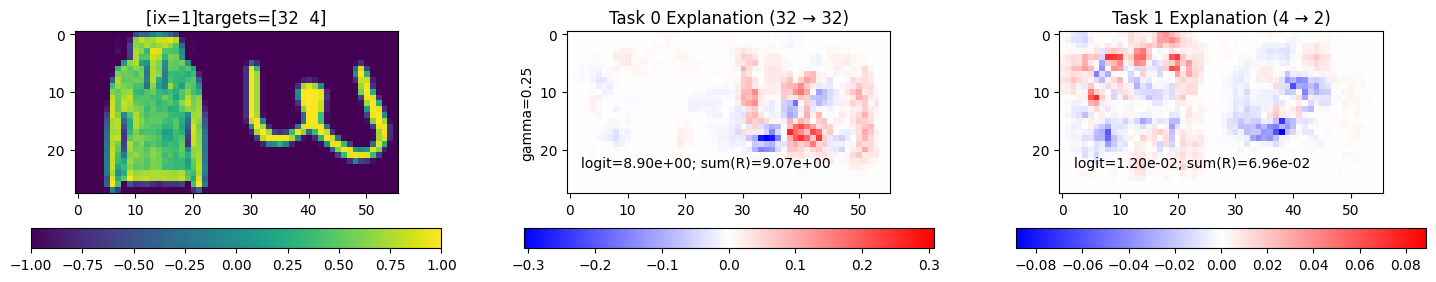

In [15]:


class TaskSpecificHeadModel(nn.Module):
    def __init__(self, model, task_id: int):
        super().__init__()
        self.model = model
        self.task_id = task_id 

    def forward(self, x):
        return self.model(x)[self.task_id]

def make_attributor(model):
    
    low = torch.tensor([-1.])
    high = torch.tensor([1.])

    composite = EpsilonGammaBox(low=low, high=high, gamma=GAMMA)

    return Gradient(model=model, composite=composite)


def sanity_check():

    task_id = 0

    logit_modifier = attributors.WinningClassEvidence(num_classes=TASK_NUM_CLASSES[task_id])
    task_specific_model = TaskSpecificHeadModel(model, task_id=task_id)
    with make_attributor(task_specific_model) as attributor:
        x = torch.randn((7, 1, 28, 28*2)).to(DEVICE)
        
        _ = attributor.forward(x, lambda logits: logit_modifier(logits, None))
    print("sanity_check: passed")

sanity_check()

def viz_explain_tasks(sample_ix):

    ncols = 3
    plt.figure(figsize=(6*ncols, 3))

    x, y = ds_val[sample_ix]
    x = x.unsqueeze(0).to(DEVICE)

    plt.subplot(1, 3, 1)
    plt.title(f"[ix={sample_ix}]targets={y}")

    plt.imshow(x.detach().cpu().numpy().squeeze())
    plt.colorbar(location="bottom")
    for task_id in [0, 1]:
        task_specific_model = TaskSpecificHeadModel(model, task_id=task_id)
        
        with make_attributor(task_specific_model) as attributor:

            task_logits, heatmap = attributor.forward(
                x, 
                lambda logits: logits * F.one_hot(torch.tensor([y[task_id]]), num_classes=TASK_NUM_CLASSES[task_id]).to(logits.device)
            )

            task_logits = task_logits.detach().cpu().numpy()
            pred = np.argmax(task_logits)

            plt.subplot(1, ncols, task_id + 2)

            plt.title(f"Task {task_id} Explanation ({y[task_id]} → {pred})")
            if task_id == 0:
                plt.ylabel(f"gamma={GAMMA}")
            heatmap = heatmap.cpu().detach().numpy().squeeze()
            plt.text(2, 28-5, f"logit={task_logits[0, y[task_id]]:.2e}; sum(R)={heatmap.sum():.2e}")
            vmax = np.abs(heatmap).max()
            plt.imshow(heatmap, cmap="bwr", vmin=-vmax, vmax=vmax)
            plt.colorbar(location="bottom")
    
viz_explain_tasks(1)

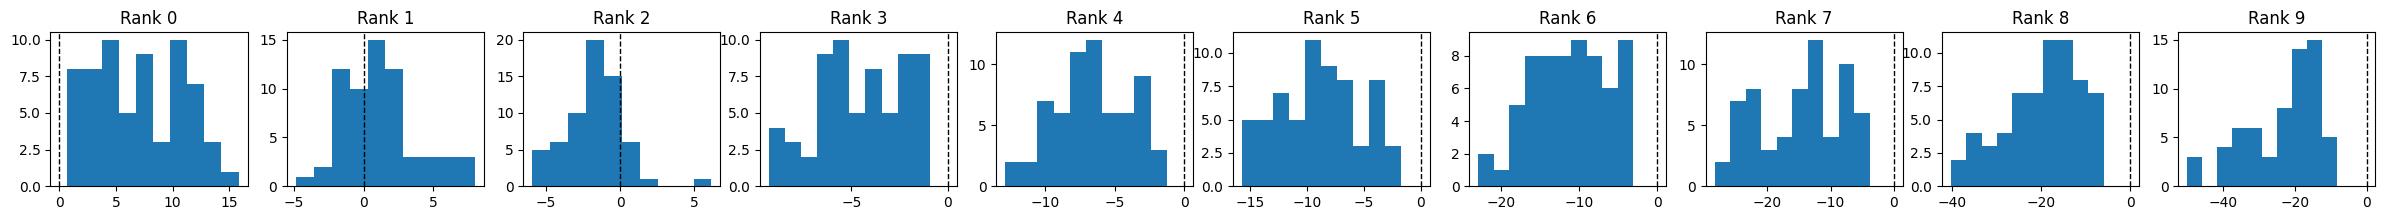

In [16]:
@torch.no_grad()
def check_winning_logits():

    ncols = 10
    task_id = 1
    plt.figure(figsize=(ncols*3, 2))
    for rank_ix in range(ncols):
        plt.subplot(1, ncols, rank_ix + 1)
        plt.title(f"Rank {rank_ix}")
        arr_winning_logits = []
        
        for x, _ in dl_train_noshuffle:
            logits = model(x.to(DEVICE))[task_id].detach().cpu()
            _, nc = logits.shape
            
            _, indices = torch.topk(logits, dim=1, k=ncols)
            one_hot = F.one_hot(
                indices[:, rank_ix], 
                num_classes=nc
            )
    
            rank_logits = (one_hot * logits).sum(dim=1)
            
            arr_winning_logits.extend(rank_logits.numpy().tolist())
    
            break
        plt.axvline(0, ls="--", lw=1, color="k")
        plt.hist(arr_winning_logits)
check_winning_logits()

# Extract Act and Ctx

In [17]:
ARR_LAYERS = ["max1", "max2", "act3"]

ARR_LAYERS

['max1', 'max2', 'act3']

In [18]:
model

CNN(
  (conv1): Conv2d(1, 256, kernel_size=(3, 3), stride=(1, 1))
  (act1): ReLU()
  (max1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
  (act2): ReLU()
  (max2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
  (act3): ReLU()
  (avgpool): AdaptiveAvgPool2d(output_size=1)
  (fc_task_1): Linear(in_features=256, out_features=47, bias=True)
  (fc_task_2): Linear(in_features=256, out_features=10, bias=True)
)

In [19]:
from collections import OrderedDict

In [20]:
def split_model_for_task(model, layer, task_id):

    arr_name_layers = list(model.named_children())

    layer_names = list(map(lambda t: t[0], arr_name_layers))
    layer_ix = layer_names.index(layer)
    avgpool_ix = layer_names.index("avgpool")


    task_module_name = f"fc_task_{task_id+1}"
    
    task_module = getattr(model, task_module_name)

    first_module = nn.Sequential(OrderedDict(
        arr_name_layers[:layer_ix+1]
    ))
    second_module = nn.Sequential(OrderedDict(
        arr_name_layers[layer_ix+1:avgpool_ix+1] 
        + [
            ("flatten", nn.Flatten(start_dim=1)),
            (task_module_name, task_module)
        ]
    ))
    
    return first_module, second_module

@torch.no_grad()
def ano():


    trng = torch.Generator()
    trng.manual_seed(1)
    
    x = torch.randn(10, 1, 28, 56, generator=trng).to(DEVICE)
    
        
    for task_id in [0, 1]:
        for layer in ARR_LAYERS:
            m1, m2 = split_model_for_task(model, layer, task_id)

            actual = m2(m1(x)).cpu().numpy()
            expected = model(x)[task_id].cpu().numpy()
            np.testing.assert_allclose(
                actual,
                expected
            )
            print(f"sanity check: task_id={task_id} layer={layer} passed!")
ano()

sanity check: task_id=0 layer=max1 passed!
sanity check: task_id=0 layer=max2 passed!
sanity check: task_id=0 layer=act3 passed!
sanity check: task_id=1 layer=max1 passed!
sanity check: task_id=1 layer=max2 passed!
sanity check: task_id=1 layer=act3 passed!


In [21]:
class PositiveWinnerNegativeOthersEvidence(attributors.LogitModifier):
    def __init__(self, num_classes: int) -> None:
        self.num_classes = num_classes

    def __call__(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        logits = logits.clone()
        wining_targets = torch.argmax(logits, dim=1)

        selecting_winner = F.one_hot(wining_targets, self.num_classes).to(
            logits.device
        )

        winning_logit = selecting_winner * logits 

        other_logits = (1-selecting_winner)  * logits

        return  winning_logit - other_logits.abs()
        

class PositiveWinnerNegativeOthersOneHotEvidence(attributors.LogitModifier):
    def __init__(self, num_classes: int) -> None:
        self.num_classes = num_classes

    def __call__(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        logits = logits.clone()
        wining_targets = torch.argmax(logits, dim=1)

        selecting_winner = F.one_hot(wining_targets, self.num_classes).to(
            logits.device
        )

        winning_logit = selecting_winner 

        other_logits = (1-selecting_winner) 

        return  winning_logit - other_logits.abs()
        


class DifferenceTop2WinningClassesEvidence(attributors.LogitModifier):
    def __init__(self, num_classes: int) -> None:
        self.num_classes = num_classes

    def __call__(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        logits = logits.clone()
        # find the label of two winning classes
        _, indices = torch.topk(logits, dim=1, k=2)
        return logits * F.one_hot(indices[:, 0], self.num_classes) - logits.abs() * F.one_hot(
            indices[:, 1], self.num_classes
        )

In [22]:

def extract_activation_context(
    model: nn.Module,
    layer: str,
    data_loader: DataLoader,
    task_id: int,
    logit_mod_name: str,
    rng: np.random.Generator,
    device="cpu",
    number_of_selected_spatial_locations=20,
    strict_mode=False,
    verbose=False
):
    arr_act = []
    arr_ctx = []

    num_classes = TASK_NUM_CLASSES[task_id]

    if logit_mod_name == "winning-class":
        logit_mod = attributors.WinningClassEvidence(num_classes=num_classes)
    elif logit_mod_name == "pos-winner-neg-others":
        logit_mod = PositiveWinnerNegativeOthersEvidence(num_classes=num_classes)
    elif logit_mod_name == "pos-winner-neg-others-onehot":
        logit_mod = PositiveWinnerNegativeOthersOneHotEvidence(num_classes=num_classes)
    elif logit_mod_name == "diff-top2winner":
        logit_mod = DifferenceTop2WinningClassesEvidence(num_classes=num_classes)
    elif logit_mod_name == "all-classes":
        logit_mod = attributors.ALlClassesEvidence(num_classes=10)
    else:
        raise NotImplemented(f"logit_mod={LOGIT_MOD} doesn't exist")

    try:
        module, hook = utils.interceptor.attach_hook_intercept_layer_output(
            model, layer, should_retain_grad=True, detach_output=False
        )

        task_specific_head = TaskSpecificHeadModel(model, task_id=task_id)

        with make_attributor(task_specific_head) as attributor:
            for batch in tqdm(data_loader, desc=f"extract act ctx (logit_mod={logit_mod_name}) at layer={layer}"):
                x, y = batch
                x = x.to(device)

                _ = attributor.forward(x, lambda logits: logit_mod(logits, y))

                act = utils.interceptor.get_output(module)

                assert act.grad is not None
                rel = act.grad

                output_dimensions = act.shape[1:]

                ctx = torch.where(act.abs() > 0, rel / act, 0)

                if strict_mode:
                    np.testing.assert_allclose(
                        (act * ctx).detach().cpu().numpy(),
                        rel.detach().cpu().numpy(),
                        atol=1e-6,
                    )

                assert ctx.shape == act.shape

                act = act.detach().cpu().numpy()
                ctx = ctx.detach().cpu().numpy()

                selected_act, selected_ctx = utils.subsample_tensors(
                    act,
                    ctx,
                    num_locations=number_of_selected_spatial_locations,
                    rng=rng,
                )
                arr_act.append(selected_act)
                arr_ctx.append(selected_ctx)

    finally:
        hook.remove()

    print(f"{layer}: output-dims={output_dimensions}")

    arr_act = np.vstack(arr_act)
    arr_ctx = np.vstack(arr_ctx)

    return arr_act, arr_ctx


def extract_act_grad(model, layer, logit_mod_name, dl, task_id):
    

  
    return extract_activation_context(
        model=model,
        layer=layer,
        data_loader=dl_train_noshuffle,
        task_id=task_id,
        logit_mod_name=logit_mod_name,
        rng=np.random.default_rng(seed=1),
        device=DEVICE
    )

extract_act_grad(model, "act3", "pos-winner-neg-others-onehot", dl_train_noshuffle, 0)

extract act ctx (logit_mod=pos-winner-neg-others-onehot) at layer=act3:   0%|          | 0/469 [00:00<?, ?it/s…

act3: output-dims=torch.Size([256, 3, 10])


(array([[ 0.      ,  0.      ,  0.      , ...,  0.      ,  0.      ,
          0.      ],
        [ 0.      ,  0.      ,  0.      , ...,  0.      ,  0.      ,
          0.      ],
        [ 0.      ,  0.      ,  0.      , ...,  0.      ,  0.      ,
          0.      ],
        ...,
        [ 0.      ,  0.      ,  0.      , ...,  0.      ,  0.      ,
          0.      ],
        [ 0.      ,  0.      ,  0.      , ...,  0.      ,  0.      ,
          0.      ],
        [ 0.      , 20.266031,  0.      , ...,  0.      ,  0.      ,
          0.      ]], dtype=float32),
 array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        ...,
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [

In [23]:
def sanity_check():
    arr_act, _ = extract_act_grad(model, dl_train_noshuffle, 0)
    
    for tidx in [1]:
        arr_act_other, _ = extract_act_grad(model, dl_train_noshuffle, tidx)
        np.testing.assert_allclose(
            arr_act_other,
            arr_act
        )
        print(f"arr_act(T0) == arr_act(T{tidx})")
    print("all passed!")
# sanity_check()

In [24]:
import torch

import numpy as np
import numpy.typing as npt


from tqdm.autonotebook import tqdm


def atol(mode):
    if mode == "reconnaive":
        return 1e-2
    else:
        return 1e-5

def exponential_map(p, g, t):
    norm_g = torch.linalg.norm(g)
    return torch.cos(norm_g * t) * p + torch.sin(norm_g * t) * (g / (norm_g + 1e-16))

In [25]:
def _solve_eigvecs(cov, sort_func=lambda x: x):
    eigvals, eigvecs = np.linalg.eigh(cov)

    assert len(eigvals.shape) == 1

    indices = np.argsort(-sort_func(eigvals))
    eigvals = eigvals[indices]
    eigvecs = eigvecs[:, indices]

    return eigvecs

def estimate_basis(basis_name, arr_act, arr_ctx, layer=None, task_id=None):
    if basis_name == "pca":
        cov = arr_act.T @ arr_act
        eigvecs = _solve_eigvecs(cov)
        return eigvecs
    elif basis_name == "cpca":
        cov = arr_ctx.T @ arr_ctx
        eigvecs = _solve_eigvecs(cov)
        return eigvecs
    elif basis_name == "prca":
        cov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        eigvecs = _solve_eigvecs(cov)
        return eigvecs
    elif basis_name == "prca-sortabs":
        cov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        eigvecs = _solve_eigvecs(cov, sort_func=np.abs)
        return eigvecs
    elif basis_name == "prca-sign-align-sortabs":
        arr_rel = (arr_act * arr_ctx).sum(axis=1, keepdims=True)
        arr_ctx_signed = (arr_rel >= 0) * arr_ctx - (arr_rel < 0) * arr_ctx
        return estimate_basis("prca-sortabs", arr_act, arr_ctx_signed)
    elif basis_name == "prca-recon-greedy":
        learner = PRCAReconGreedy()
        return learner.fit(activation=arr_act, context=arr_ctx, device=DEVICE)
    elif basis_name == "prca-sign-align-greedy":
        return PRCASignAlignGreedy().fit(activation=arr_act, context=arr_ctx, device=DEVICE)
    elif  "pca-lh" in basis_name:
        _, k = basis_name.split("k")
        k = int(k)

        first_module, second_module = split_model_for_task(model, layer=layer, task_id=task_id) 

        U =  pcalookahead.fit_v2(
            first_module=first_module,
            second_module=second_module,
            dataloader=dl_train,
            Uinit=estimate_basis("prca-sign-align-sortabs", arr_act, arr_ctx)[:, :k],
            k=k,
            epochs=5,
            verbose=True,
            device=DEVICE
        )
        np.testing.assert_allclose(
            U.T @ U,
            np.eye(k),
            atol=1e-5
        )

        return U
    elif basis_name == "DevPRCAReconBugFix":
        return DevPRCAReconBugFix().fit(activation=arr_act, context=arr_ctx, device=DEVICE)
    else:
        raise NotImplementedError(f"{basis_name} doesn't exist")


        
def construct_fh(Uk):
    def fh(mod, inp, outp):
        return F.conv2d(
            outp,
            (Uk@Uk.T).unsqueeze(2).unsqueeze(3)
        )
    return fh

def compute_task_acc_at_k(
    model, layer, task_id, logit_mod_name, arr_ks,
    arr_basis_names=["pca", "prca-signed", "prca-recon"]
):
    arr_act, arr_ctx = extract_act_grad(model, layer, logit_mod_name, dl_train_noshuffle, task_id)
    arr_stat_rows = []
    
    module = getattr(model, layer)

    rel = (arr_act  * arr_ctx).sum(axis=1)
    
    for basis_name in arr_basis_names:
        U = estimate_basis(basis_name, arr_act, arr_ctx, layer=layer, task_id=task_id)
        for k in tqdm(arr_ks, desc=f"[{basis_name}] estimating performance"):

            if "pca-lh" in basis_name  and not f"{k}" == basis_name.split("k")[1]:
                continue


            Uk = U[:, :k]

            arr_recon_act = (arr_act @ Uk) @ Uk.T

            recon_err = np.linalg.norm(arr_act - arr_recon_act, axis=1).mean()
            projected_rel = ((arr_act @ Uk) * (arr_ctx @ Uk)).sum(axis=1)
            rel_recon_err = ((rel - projected_rel) **2).mean()
            assert rel.shape == projected_rel.shape == (rel.shape[0], )
            perc_sign_align = (np.sign(rel) * np.sign(projected_rel)).mean()
            
            Uk = torch.from_numpy(Uk).to(DEVICE)
            row = dict(
                layer=layer,
                task_id=task_id, 
                logit_mod=logit_mod_name,
                gamma=GAMMA,
                k=k, 

                basis_name=basis_name,
                recon_err=recon_err,
                rel_recon_err=rel_recon_err,
                perc_sign_align=perc_sign_align,
            )
            try:
                hook = module.register_forward_hook(construct_fh(Uk))
                
                for label, dl in [
                    # ("train", dl_train_noshuffle),
                    ("test", dl_test)
                ]:
                    row[f"acc_{label}"], row[f"xent_{label}"] = estimate_task_acc(model, dl, task_id)
                
            finally:
                hook.remove()
            arr_stat_rows.append(row)
            
    df = pd.DataFrame(arr_stat_rows).sort_values(by=["k", "acc_test"], ascending=[True, False])

    return df



# logit_mod_list = winning-class, pos-winner-neg-others, pos-winner-neg-others-onehot, diff-top2winner, all-classes
    


compute_task_acc_at_k(
    model, layer="max2", 
    task_id=1, 
    logit_mod_name="winning-class", 
    arr_ks=[5, 10, 15],
     arr_basis_names=[
         # "dev-prca-recon",
         "pca", 
         # "prca-sortabs",
         # "prca-sign-align-sortabs",      
         "prca-recon-greedy",
         "prca-sign-align-greedy",
         # "pca-lh-k5",
         # "pca-lh-k10",
         # "pca-lh-k15",
     ]
)

extract act ctx (logit_mod=winning-class) at layer=max2:   0%|          | 0/469 [00:00<?, ?it/s]

max2: output-dims=torch.Size([256, 5, 12])


[pca] estimating performance:   0%|          | 0/3 [00:00<?, ?it/s]

PRCA Recon [device=cuda]]:   0%|          | 0/256 [00:00<?, ?it/s]

[prca-recon-greedy] estimating performance:   0%|          | 0/3 [00:00<?, ?it/s]

PRCASignAlignGreedy [device=cuda]]:   0%|          | 0/256 [00:00<?, ?it/s]

[prca-sign-align-greedy] estimating performance:   0%|          | 0/3 [00:00<?, ?it/s]

,layer,task_id,logit_mod,gamma,k,basis_name,recon_err,rel_recon_err,perc_sign_align,acc_test,xent_test
6,max2,1,winning-class,0.25,5,prca-sign-align-greedy,47.159775,0.027605,0.667528,0.5809,2.463282
3,max2,1,winning-class,0.25,5,prca-recon-greedy,47.852848,0.026178,0.675868,0.4748,2.739698
0,max2,1,winning-class,0.25,5,pca,36.572441,0.065152,0.731945,0.2543,2.761811
7,max2,1,winning-class,0.25,10,prca-sign-align-greedy,26.082729,0.007409,0.848555,0.8061,0.690754
1,max2,1,winning-class,0.25,10,pca,20.949139,0.015057,0.863422,0.8047,0.675864
4,max2,1,winning-class,0.25,10,prca-recon-greedy,27.888849,0.008294,0.836802,0.7282,0.978544
8,max2,1,winning-class,0.25,15,prca-sign-align-greedy,11.537651,0.001135,0.931775,0.8790,0.377171
2,max2,1,winning-class,0.25,15,pca,8.533335,0.002001,0.940505,0.8788,0.375286
5,max2,1,winning-class,0.25,15,prca-recon-greedy,13.481689,0.001217,0.928105,0.8744,0.395026


# Accuracy Curves

In [26]:
def get_dims(layer):
    return {
        "max1": 256,
        "max2": 256,
        "act3": 256,
    }[layer]

In [27]:
DATA_SIZE

0.5

extract act ctx (logit_mod=winning-class) at layer=act3:   0%|          | 0/469 [00:00<?, ?it/s]

act3: output-dims=torch.Size([256, 3, 10])


[pca] estimating performance:   0%|          | 0/13 [00:00<?, ?it/s]

[prca-sortabs] estimating performance:   0%|          | 0/13 [00:00<?, ?it/s]

PRCA Recon [device=cuda]]:   0%|          | 0/256 [00:00<?, ?it/s]

...

act3: output-dims=torch.Size([256, 3, 10])


[pca] estimating performance:   0%|          | 0/13 [00:00<?, ?it/s]

[prca-sortabs] estimating performance:   0%|          | 0/13 [00:00<?, ?it/s]

PRCA Recon [device=cuda]]:   0%|          | 0/256 [00:00<?, ?it/s]

[prca-recon-greedy] estimating performance:   0%|          | 0/13 [00:00<?, ?it/s]

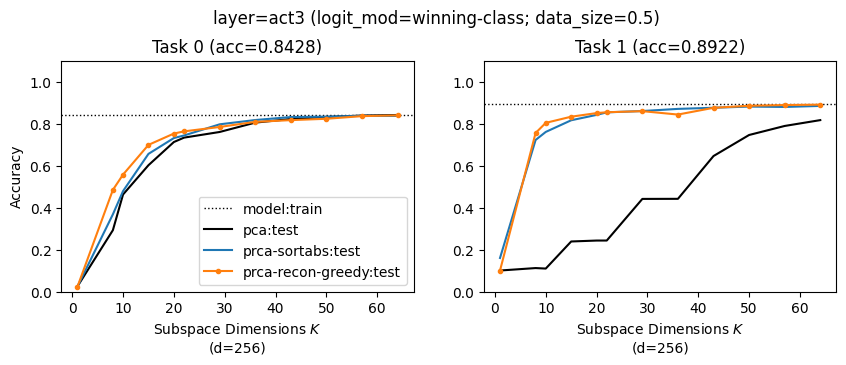

In [28]:
def marker(basis_name):
    if "greedy" in basis_name:
        return "."
    elif "-lh" in basis_name:
        return "*"
    else:
        return None
        
def color(basis_name):
    if basis_name == "pca":
        return "black"
    elif "pca-lh" in basis_name:
        return "blue"
    else:
        return None
        
def viz(layer,
    arr_basis_names = [
        "pca",
        "prca-sortabs",
        "prca-recon-greedy",
        
        # "pca-lh-k10",
        # "pca-lh-k20",
    ]
):
    
    arr_task_ids = np.arange(2)
    ncols = arr_task_ids.shape[0]
    plt.figure(figsize=(5*ncols, 3))
    
    logit_mod_name="winning-class"

   

    arr_pca_lh_names = list(filter(lambda t: "pca-lh" in t, arr_basis_names))

    d = get_dims(layer)
    arr_ks = np.linspace(1, d // 4, 10).astype(int).tolist() + [d]
    
    arr_ks = arr_ks +[10, 20] # for pca-lh
    arr_ks = sorted(list(set(arr_ks)))
    plt.suptitle(f"layer={layer} (logit_mod={logit_mod_name}; data_size={DATA_SIZE})", y=1.05)
    
    for task_id in arr_task_ids:
        plt.subplot(1, ncols, task_id+1)
        
        df = compute_task_acc_at_k(
            model, layer=layer, task_id=task_id, logit_mod_name=logit_mod_name, arr_ks=arr_ks,
            arr_basis_names=arr_basis_names
        )
        
        for bix, basis_name in enumerate(arr_basis_names):
            _df = df[
                (df.basis_name == basis_name)
            ]
            
            if bix == 0:
                
                ref = ref_stats[f"acc_task_{task_id}_test"]
                plt.title(f"Task {task_id} (acc={ref:.4f})")

                plt.axhline(
                    ref,
                    ls=":",
                    lw=1,
                    color="k",
                    label="model:train"
                )

            selected = _df.k <= 64
            
            for label in ["test"]:
                if "pca-lh" in basis_name:
                    plt.scatter(
                        _df.k[selected],
                        _df[f"acc_{label}"][selected],
                        color=color(basis_name),
                        marker=marker(basis_name),
                        label=f"pca-lh:{label}" if basis_name == arr_pca_lh_names[-1] else None
                    )
                else:
                    plt.plot(
                        _df.k[selected],
                        _df[f"acc_{label}"][selected],
                        color=color(basis_name),
                        ls="-",
                        marker=marker(basis_name),
                        label=f"{basis_name}:{label}"
                    )
        plt.ylim([0.0, 1.1])
        if task_id == 0:
            plt.legend()
            plt.ylabel("Accuracy")
        plt.xlabel(f"Subspace Dimensions $K$\n(d={d})")
        
viz(layer="act3")

extract act ctx (logit_mod=winning-class) at layer=act3:   0%|          | 0/469 [00:00<?, ?it/s]

act3: output-dims=torch.Size([256, 3, 10])


[pca] estimating performance:   0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

...

[prca-sortabs] estimating performance:   0%|          | 0/13 [00:00<?, ?it/s]

PRCA Recon [device=cuda]]:   0%|          | 0/256 [00:00<?, ?it/s]

[prca-recon-greedy] estimating performance:   0%|          | 0/13 [00:00<?, ?it/s]

PRCASignAlignGreedy [device=cuda]]:   0%|          | 0/256 [00:00<?, ?it/s]

[prca-sign-align-greedy] estimating performance:   0%|          | 0/13 [00:00<?, ?it/s]

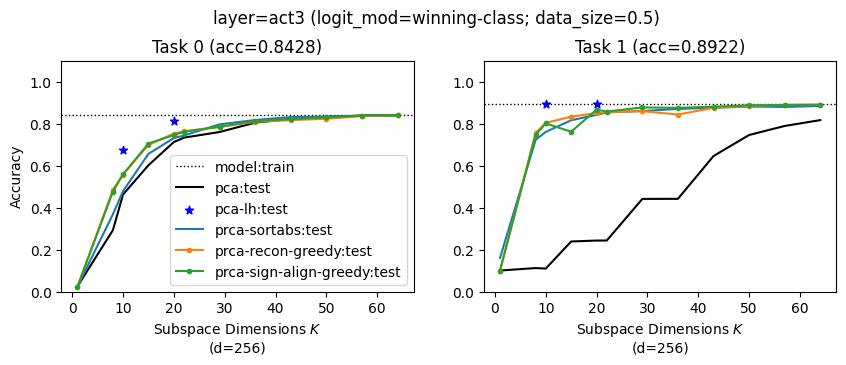

extract act ctx (logit_mod=winning-class) at layer=max2:   0%|          | 0/469 [00:00<?, ?it/s]

max2: output-dims=torch.Size([256, 5, 12])


[pca] estimating performance:   0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

...

[prca-sortabs] estimating performance:   0%|          | 0/13 [00:00<?, ?it/s]

PRCA Recon [device=cuda]]:   0%|          | 0/256 [00:00<?, ?it/s]

[prca-recon-greedy] estimating performance:   0%|          | 0/13 [00:00<?, ?it/s]

PRCASignAlignGreedy [device=cuda]]:   0%|          | 0/256 [00:00<?, ?it/s]

[prca-sign-align-greedy] estimating performance:   0%|          | 0/13 [00:00<?, ?it/s]

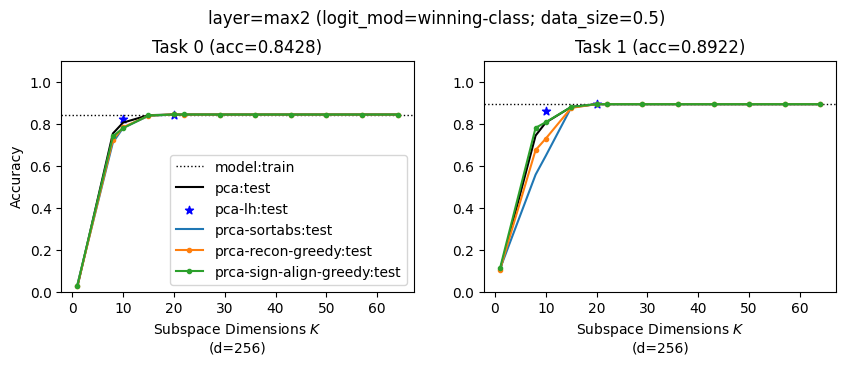

extract act ctx (logit_mod=winning-class) at layer=max1:   0%|          | 0/469 [00:00<?, ?it/s]

max1: output-dims=torch.Size([256, 13, 27])


[pca] estimating performance:   0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

...

[prca-sortabs] estimating performance:   0%|          | 0/13 [00:00<?, ?it/s]

PRCA Recon [device=cuda]]:   0%|          | 0/256 [00:00<?, ?it/s]

[prca-recon-greedy] estimating performance:   0%|          | 0/13 [00:00<?, ?it/s]

PRCASignAlignGreedy [device=cuda]]:   0%|          | 0/256 [00:00<?, ?it/s]

[prca-sign-align-greedy] estimating performance:   0%|          | 0/13 [00:00<?, ?it/s]

In [ ]:
for layer in ["act3", "max2", "max1"]:
    viz(
        arr_basis_names=[
            "pca",
            "pca-lh-k10",
            "pca-lh-k20",
            "prca-sortabs",
            "prca-recon-greedy",
            "prca-sign-align-greedy",
        ],
        layer=layer
    )
    plt.show()

In [ ]:
for layer in ["act3", "max2", "max1"]:
    viz(
        arr_basis_names=[
            "pca",
            "pca-lh-k10",
            "pca-lh-k20",
            "prca-sortabs",
            "prca-sign-align-sortabs",
            "prca-recon-greedy",
        ],
        layer=layer
    )
    plt.show()

In [ ]:
print(f"Finished at {datetime.now()}")